<h1 align="center">Loan repayment prediction</h1>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns
from scipy.stats import chi2_contingency
from scipy.stats import ks_2samp

# Loading Data

In [2]:
train = pd.read_csv('../data/train.csv')

test = pd.read_csv('../data/test.csv')

## Feature Definitions

In [3]:
numerical_cols = ['annual_income', 'debt_to_income_ratio', 'credit_score', 
                  'loan_amount', 'interest_rate']


categorical_cols = ['gender', 'marital_status', 'education_level', 
                    'employment_status', 'loan_purpose', 'grade_subgrade']

## Data Inspection

**Shape & columns**

In [4]:
pd.DataFrame({
    'rows': [train.shape[0], test.shape[0]],
    'columns': [train.shape[1], test.shape[1]]
}, index=['train', 'test'])

,rows,columns
train,593994,13
test,254569,12


- Train dataset has 593,994 rows and 13 columns
- Test dataset has 254,569 rows and 12 columns

In [5]:
print(set(train.columns) - set(test.columns))

{'loan_paid_back'}


- The only difference is `loan_paid_back` — the target variable, which is expected as test set does not contain labels.

**Preview**

In [6]:
display(train.head())

display(test.head())

,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade,loan_paid_back
0,0,29367.99,0.084,736,2528.42,13.67,Female,Single,High School,Self-employed,Other,C3,1.0
1,1,22108.02,0.166,636,4593.10,12.92,Male,Married,Master's,Employed,Debt consolidation,D3,0.0
2,2,49566.20,0.097,694,17005.15,9.76,Male,Single,High School,Employed,Debt consolidation,C5,1.0
3,3,46858.25,0.065,533,4682.48,16.10,Female,Single,High School,Employed,Debt consolidation,F1,1.0
4,4,25496.70,0.053,665,12184.43,10.21,Male,Married,High School,Employed,Other,D1,1.0


,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade
0,593994,28781.05,0.049,626,11461.42,14.73,Female,Single,High School,Employed,Other,D5
1,593995,46626.39,0.093,732,15492.25,12.85,Female,Married,Master's,Employed,Other,C1
2,593996,54954.89,0.367,611,3796.41,13.29,Male,Single,Bachelor's,Employed,Debt consolidation,D1
3,593997,25644.63,0.110,671,6574.30,9.57,Female,Single,Bachelor's,Employed,Debt consolidation,C3
4,593998,25169.64,0.081,688,17696.89,12.80,Female,Married,PhD,Employed,Business,C1


**Observations for train dataset:**
- Mix of numerical features: `annual_income`, `debt_to_income_ratio`, `credit_score`, `loan_amount`, `interest_rate`
- Mix of categorical features: `gender`, `marital_status`, `education_level`, `employment_status`, `loan_purpose`, `grade_subgrade`
- Target `loan_paid_back` is binary (0.0 and 1.0)
- `grade_subgrade` is a letter+number code (C3, D3, F1 etc.)

**Observations for test dataset:**
- Same structure as train — columns align as expected

**Info and missing values**

In [7]:
print("=== TRAIN ===")
train.info()
print(train.isnull().sum())

print("\n=== TEST ===")
test.info()
print(test.isnull().sum())

=== TRAIN ===
<class 'pandas.DataFrame'>
RangeIndex: 593994 entries, 0 to 593993
Data columns (total 13 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    593994 non-null  int64  
 1   annual_income         593994 non-null  float64
 2   debt_to_income_ratio  593994 non-null  float64
 3   credit_score          593994 non-null  int64  
 4   loan_amount           593994 non-null  float64
 5   interest_rate         593994 non-null  float64
 6   gender                593994 non-null  str    
 7   marital_status        593994 non-null  str    
 8   education_level       593994 non-null  str    
 9   employment_status     593994 non-null  str    
 10  loan_purpose          593994 non-null  str    
 11  grade_subgrade        593994 non-null  str    
 12  loan_paid_back        593994 non-null  float64
dtypes: float64(5), int64(2), str(6)
memory usage: 58.9 MB
id                      0
annual_income        

**Observations for train dataset:**
- No missing values across all features
- 5 float64 (annual_income, debt_to_income_ratio, loan_amount, interest_rate, loan_paid_back), 2 int64 (id, credit_score), 6 str (all categoricals)
- loan_paid_back is float64 — casting to int recommended
- Dtype casting for some features is recommended:  loan_paid_back -> int (target variable), grade_subgrade, possibly education_level -> ordinal - possible ordinals should be more thoroughly examined.
- id is int — should be dropped before training, no predictive value

**Observations for test dataset:**
- Same structure as train minus loan_paid_back, no missing values — clean and consistent.


**Duplicates**

In [8]:
print(f"Duplicate rows for train: {train.duplicated().sum()}")
print(f"Duplicate IDs for train: {train['id'].duplicated().sum()}")

print()

print(f"Duplicate rows for test: {test.duplicated().sum()}")
print(f"Duplicate IDs for test: {test['id'].duplicated().sum()}")

Duplicate rows for train: 0
Duplicate IDs for train: 0

Duplicate rows for test: 0
Duplicate IDs for test: 0


- No duplicate rows found in both test as well as train — datasets are clean.

In [9]:
print("Negative values in train dataset:")
print((train[['annual_income', 'loan_amount', 'interest_rate', 'credit_score']] < 0).sum())

print("\nNegative values in test dataset:")
print((test[['annual_income', 'loan_amount', 'interest_rate', 'credit_score']] < 0).sum())

Negative values in train dataset:
annual_income    0
loan_amount      0
interest_rate    0
credit_score     0
dtype: int64

Negative values in test dataset:
annual_income    0
loan_amount      0
interest_rate    0
credit_score     0
dtype: int64


- No negative values present in both datasets

# Domain Validation

In [10]:
print("=== TRAIN ===")
print(f"Credit score out of range: {((train['credit_score'] < 300) | (train['credit_score'] > 850)).sum()}")
print(f"Interest rate out of range: {((train['interest_rate'] < 0) | (train['interest_rate'] > 100)).sum()}")
print(f"Debt ratio > 1: {(train['debt_to_income_ratio'] > 1).sum()}")


print("\n=== TEST ===")
print(f"Credit score out of range: {((test['credit_score'] < 300) | (test['credit_score'] > 850)).sum()}")
print(f"Interest rate out of range: {((test['interest_rate'] < 0) | (test['interest_rate'] > 100)).sum()}")
print(f"Debt ratio > 1: {(test['debt_to_income_ratio'] > 1).sum()}")

=== TRAIN ===
Credit score out of range: 0
Interest rate out of range: 0
Debt ratio > 1: 0

=== TEST ===
Credit score out of range: 0
Interest rate out of range: 0
Debt ratio > 1: 0


- No impossible values detected in both datasets — credit scores, interest rates, and debt ratios are all within realistic ranges

# Distribution Shift

In [11]:
print("Numerical columns KS test:")
print()
for col in numerical_cols:
    stat, p = ks_2samp(train[col], test[col])
    print(f"{col}: KS={stat:.4f}, p={p:.4f}")

print("\nCategorical columns KS test:")
print()
for col in categorical_cols:
    stat, p = ks_2samp(
        train[col].astype('category').cat.codes,
        test[col].astype('category').cat.codes
    )
    print(f"{col}: KS={stat:.4f}, p={p:.4f}")

Numerical columns KS test:

annual_income: KS=0.0019, p=0.5390
debt_to_income_ratio: KS=0.0021, p=0.4336
credit_score: KS=0.0019, p=0.5560
loan_amount: KS=0.0017, p=0.6786
interest_rate: KS=0.0026, p=0.1807

Categorical columns KS test:

gender: KS=0.0010, p=0.9915
marital_status: KS=0.0007, p=1.0000
education_level: KS=0.0004, p=1.0000
employment_status: KS=0.0005, p=1.0000
loan_purpose: KS=0.0013, p=0.9340
grade_subgrade: KS=0.0018, p=0.5988


- All KS statistics are under 0.003 and all p-values well above 0.05 — no distribution drift detected in any feature. Categorical features are especially consistent, with p-values near 1.0 for several columns.

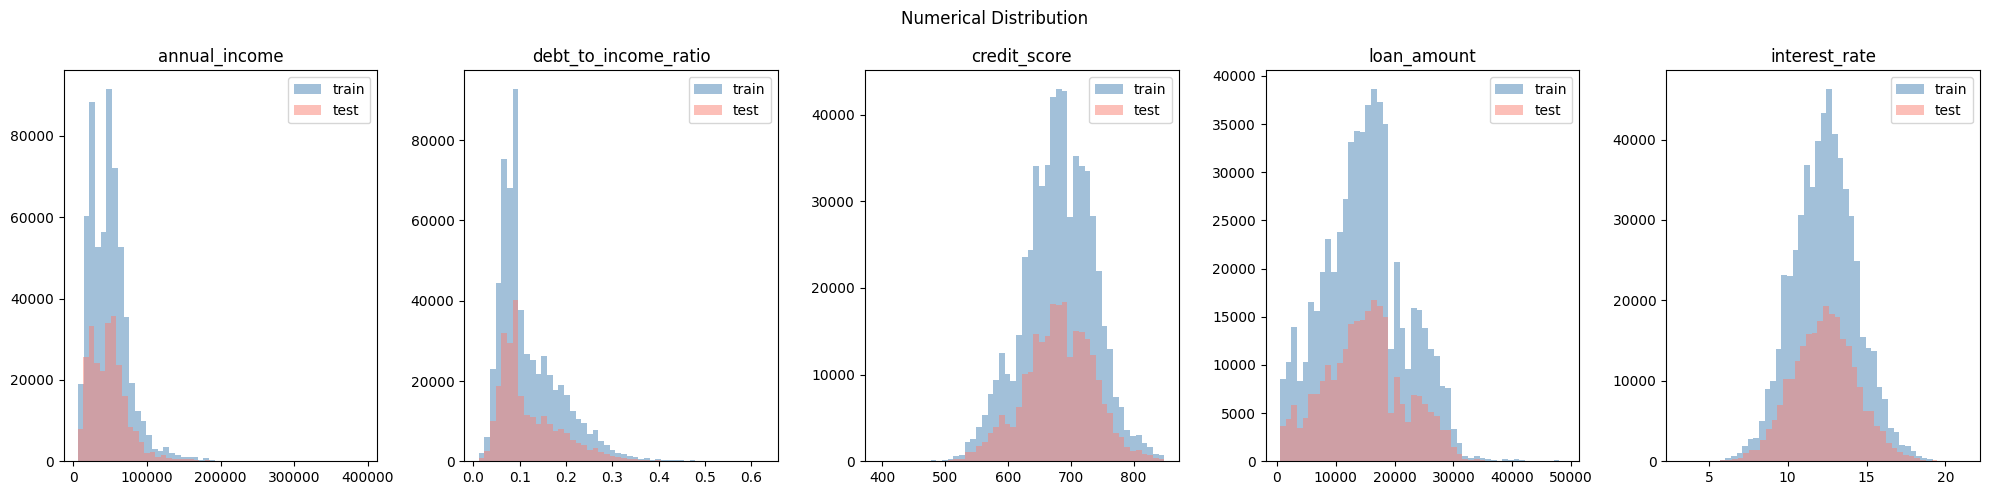

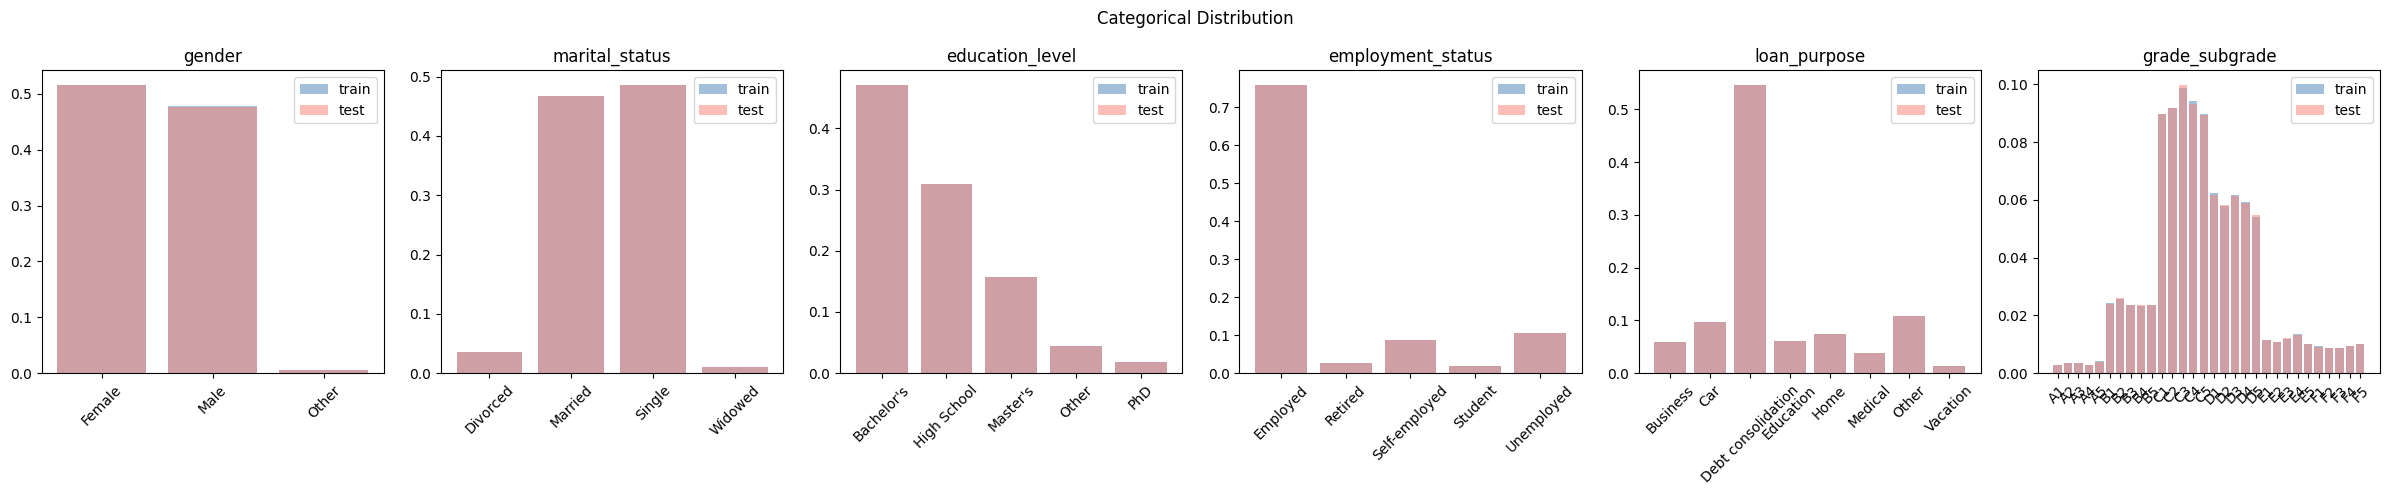

In [12]:
def plot_dist(cols, title, plot_type='hist'):
    n = len(cols)
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 5))
    
    for i, col in enumerate(cols):
        ax = axes[i]
        if plot_type == 'hist':
            ax.hist(train[col], bins=50, alpha=0.5, color='steelblue', label='train')
            ax.hist(test[col], bins=50, alpha=0.5, color='salmon', label='test')
        else:
            all_cats = sorted(set(train[col].unique()) | set(test[col].unique()))
            train_pct = train[col].value_counts(normalize=True).reindex(all_cats, fill_value=0)
            test_pct = test[col].value_counts(normalize=True).reindex(all_cats, fill_value=0)
            ax.bar(all_cats, train_pct, alpha=0.5, color='steelblue', label='train')
            ax.bar(all_cats, test_pct, alpha=0.5, color='salmon', label='test')
            ax.tick_params(axis='x', rotation=45)
            
        ax.set_title(col)
        ax.legend()
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


plot_dist(numerical_cols, 'Numerical Distribution')
plot_dist(categorical_cols, 'Categorical Distribution', 'bar')

**Observations**

Numerical:

- All features overlap almost perfectly — shapes, peaks, and ranges are identical across train and test
Blue bars are taller simply due to train being ~2.3x larger, not distribution shift

Categorical:

- Category proportions are consistent across all features
grade_subgrade shows matching distribution across all 30 categories
No missing or extra categories in either dataset

<h2 align="center">Final conclusion for test dataset</h2>
- The most relevant inspections for test dataset have been done, and no signs of errors or unrealistic/missing values — the dataset does not have a target variable so the inspection is complete.

**Note**:
- Although normally most appropriate would it be to check both train and test dataset in separate cells, but in this case I have decided it is much more readable to do those checkings in one, becuase both datasets were generated from the original and do not need pre-cleaning and have very similar structure, so it is more readable, much cleaner and less repetitious to read. 
- Additionaly, the test datasets cells were not much described, because of the dataset low relevance - pure and core focus was put into checking correctness, not analysis - train dataset were much broadly described with recommended actions.

## Target variable analysis

In [13]:
counts = train['loan_paid_back'].value_counts()

pct = train['loan_paid_back'].value_counts(normalize=True) * 100 # converting to percentage - just for better readability

print(counts)
print()
print(pct.round(1))


loan_paid_back
1.0    474494
0.0    119500
Name: count, dtype: int64

loan_paid_back
1.0    79.9
0.0    20.1
Name: proportion, dtype: float64


**Observation:**

- 474,494 repaid (79.9%) vs 119,500 not repaid (20.1%) — ~4:1 class imbalance - might be needed to be handled

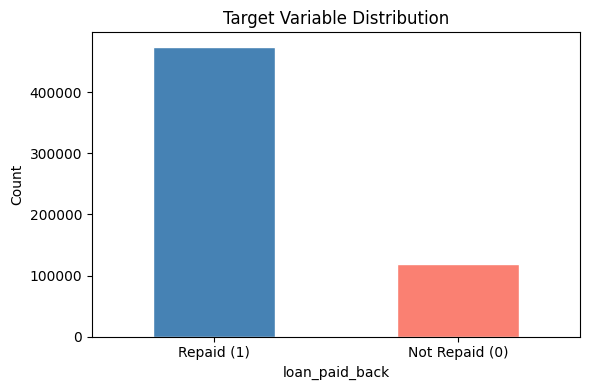

In [14]:
counts.plot(kind='bar', color=['steelblue', 'salmon'], edgecolor='white', figsize=(6, 4))
plt.xticks([0, 1], ['Repaid (1)', 'Not Repaid (0)'], rotation=0)
plt.title('Target Variable Distribution')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

- Visual confirmation of the ~4:1 class imbalance reported in the statistics above.

## Univariate Analysis

**Categorical feature inspection**

In [15]:
for col in train.select_dtypes(include='str').columns:
    print(f"{col} ({train[col].nunique()} unique): {train[col].unique()}")
    print()

gender (3 unique): <StringArray>
['Female', 'Male', 'Other']
Length: 3, dtype: str

marital_status (4 unique): <StringArray>
['Single', 'Married', 'Divorced', 'Widowed']
Length: 4, dtype: str

education_level (5 unique): <StringArray>
['High School', 'Master's', 'Bachelor's', 'PhD', 'Other']
Length: 5, dtype: str

employment_status (5 unique): <StringArray>
['Self-employed', 'Employed', 'Unemployed', 'Retired', 'Student']
Length: 5, dtype: str

loan_purpose (8 unique): <StringArray>
[             'Other', 'Debt consolidation',               'Home',
          'Education',           'Vacation',                'Car',
            'Medical',           'Business']
Length: 8, dtype: str

grade_subgrade (30 unique): <StringArray>
['C3', 'D3', 'C5', 'F1', 'D1', 'D5', 'C2', 'C1', 'F5', 'D4', 'C4', 'D2', 'E5',
 'B1', 'B2', 'F4', 'A4', 'E1', 'F2', 'B4', 'E4', 'B3', 'E3', 'B5', 'E2', 'F3',
 'A5', 'A3', 'A1', 'A2']
Length: 30, dtype: str



**Observation:**
- No inconsistent formatting — all values are clean and consistently capitalized
- `grade_subgrade`: 30 unique values — high cardinality - suspected ordinal structure - to be determined
- `loan_purpose`: 8 unique values — moderate cardinality
-  All others have low cardinality (3-5 values) — one-hot or ordinal depending on whether natural order exists could be appropriate.

In [16]:
for col in train.select_dtypes(include='str').columns:
    print(f"\n{col}:")
    print(train[col].value_counts(normalize=True).round(3))


gender:
gender
Female    0.515
Male      0.478
Other     0.006
Name: proportion, dtype: float64

marital_status:
marital_status
Single      0.486
Married     0.467
Divorced    0.036
Widowed     0.011
Name: proportion, dtype: float64

education_level:
education_level
Bachelor's     0.471
High School    0.309
Master's       0.157
Other          0.045
PhD            0.019
Name: proportion, dtype: float64

employment_status:
employment_status
Employed         0.759
Unemployed       0.105
Self-employed    0.088
Retired          0.028
Student          0.020
Name: proportion, dtype: float64

loan_purpose:
loan_purpose
Debt consolidation    0.547
Other                 0.108
Car                   0.098
Home                  0.074
Education             0.062
Business              0.059
Medical               0.038
Vacation              0.014
Name: proportion, dtype: float64

grade_subgrade:
grade_subgrade
C3    0.099
C4    0.094
C2    0.092
C1    0.090
C5    0.090
D1    0.062
D3    0.062
D4    0

**Observations (Relative Frequency Distribution):**
- `gender`: balanced — Female 51.5%, Male 47.8%, Other 0.6% rare
- `marital_status`: balanced — Single/Married ~95%, Divorced and Widowed rare
- `education_level`: Bachelor's dominant (47.1%), PhD and Other rare
- `employment_status`: strongly imbalanced — Employed 75.9%, Retired and Student rare
- `loan_purpose`: imbalanced — Debt consolidation 54.7%, Vacation and Medical rare
- `grade_subgrade`: C-grade dominates (~46% combined), A-grades extremely rare, 30 categories total

In [17]:
print("Gender:")
display(train['gender'].value_counts())

print("\nloan_paid_back:")
display(train['loan_paid_back'].unique())

print("\nEducation level:")
display(train['education_level'].unique())

Gender:


gender
Female    306175
Male      284091
Other       3728
Name: count, dtype: int64


loan_paid_back:


array([1., 0.])


Education level:


<StringArray>
['High School', 'Master's', 'Bachelor's', 'PhD', 'Other']
Length: 5, dtype: str

- 3 different types for `gender`, so it stays as str - not binary 
- as expected only two values for `loan_paid_back` - binary
- education level has 4 concrete types + 1 ambigious : `other`


**Numerical feature inspection**

In [18]:
train.describe().round(2) # 2 decimal places instead of 6 which are hard to read and provide little value

,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,loan_paid_back
count,593994.00,593994.00,593994.00,593994.00,593994.00,593994.00,593994.0
mean,296996.50,48212.20,0.12,680.92,15020.30,12.36,0.8
std,171471.44,26711.94,0.07,55.42,6926.53,2.01,0.4
min,0.00,6002.43,0.01,395.00,500.09,3.20,0.0
25%,148498.25,27934.40,0.07,646.00,10279.62,10.99,1.0
50%,296996.50,46557.68,0.10,682.00,15000.22,12.37,1.0
75%,445494.75,60981.32,0.16,719.00,18858.58,13.68,1.0
max,593993.00,393381.74,0.63,849.00,48959.95,20.99,1.0


**Observations:**
- `annual_income`:  mean 48k, max 393k, std 26k — high spread, strong right skew likely
- `debt_to_income_ratio`:  median 0.10 but max 0.63 — tight core, wide upper tail
- `credit_score`: mean 681, std 55 — realistic, well-centered
- `loan_amount`:  mean 15k, max 49k, std 6.9k — wide spread, to be examined further
- `interest_rate`: mean 12.36, std 2.01 — tight, realistic distribution, no concerns

## Skewness 

**Note:** 
With 594k rows the normal statistical test for skewness would detect even trivial deviations from normality, so skewness statistics and visualizations are preffered over it.

In [19]:
print(train[numerical_cols].skew().round(2)) # on entire dataset, not just sample, to confirm skewness is present in full data

annual_income           1.72
debt_to_income_ratio    1.41
credit_score           -0.17
loan_amount             0.21
interest_rate           0.05
dtype: float64


**Observations (skewness):**
- `annual_income`: heavily right skewed 
- `debt_to_income_ratio`: heavily right skewed
- `credit_score`: Relatively Normal (slight left skew)
- `loan_amount`: Relatively Normal (slight right skewed)
- `interest_rate`: Normal
- `annual_income` and `debt_to_income_ratio`  may require transformation depending on model choice.

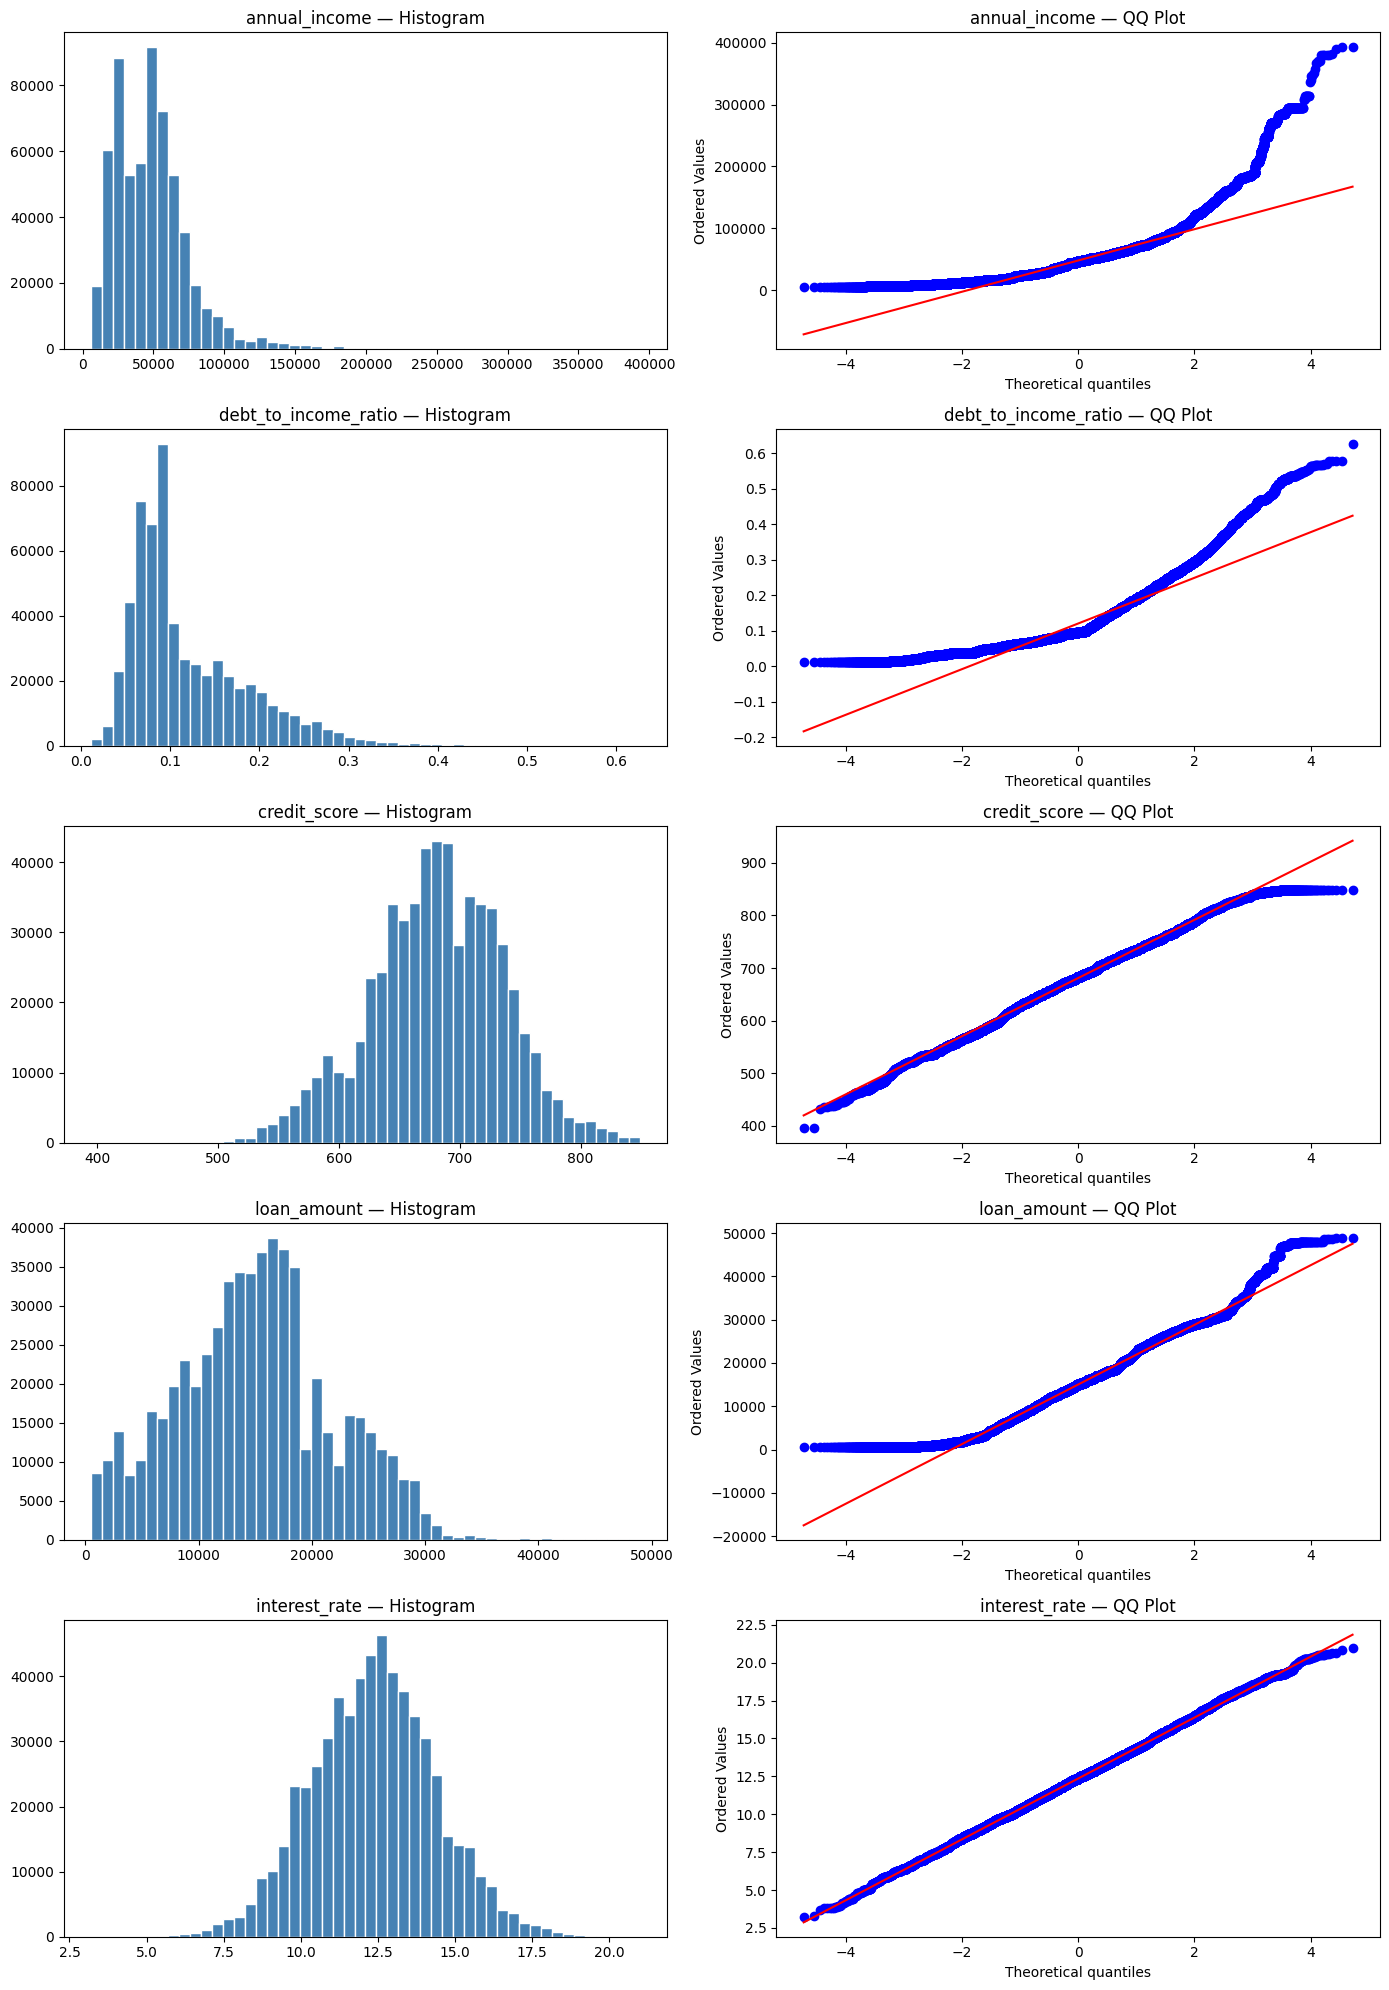

In [20]:
fig, axes = plt.subplots(len(numerical_cols), 2, figsize=(14, 20))

for i, col in enumerate(numerical_cols):
    
    # Histogram
    axes[i, 0].hist(train[col], bins=50, color='steelblue', edgecolor='white')
    axes[i, 0].set_title(f'{col} — Histogram')
    
    # QQ Plot
    stats.probplot(train[col], dist="norm", plot=axes[i, 1])
    axes[i, 1].set_title(f'{col} — QQ Plot')

plt.tight_layout()
plt.show()

**Observations (Histogram + QQ Plot):**
- `annual_income`: strong right-skewed visible — QQ upper tail shoots far above the line, extreme outliers confirmed
- `debt_to_income_ratio`: right-skewed, values concentrated near 0 — QQ upper tail deviation confirms non-normality
- `credit_score`: approximately normal (with small multimodality) — QQ nearly straight, slight ceiling effect at 850 (max possible score)
- `loan_amount`: mildly right-skewed with slight bimodality (10k and 20k), lower tail compressed — QQ upper tail curves above line
- `interest_rate`: symmetric — QQ nearly perfect straight line fit

Should be investigated more regarding outliers - especially `annual_income` and `debt_to_income_ratio`

## Kurtosis 

In [21]:
print(train[numerical_cols].kurtosis().round(2))

annual_income           7.09
debt_to_income_ratio    2.34
credit_score            0.10
loan_amount            -0.15
interest_rate           0.06
dtype: float64


**Observations (Kurtosis):**
- `annual_income`: 7.09 — extremely heavy tails, extreme outliers confirmed
- `debt_to_income_ratio`: 2.34 — moderately heavy tails, outliers present but less severe
- `credit_score`: 0.10 — normal tail behavior, no outlier concern
- `loan_amount`: -0.15 — lighter tails than normal, non-normality driven by clustering not outliers
- `interest_rate`: 0.06 — normal tail behavior, no outlier concern

Extreme outliers may require handling depending on model choice.

## Outlier Analysis

In [22]:
# Some features are heavily right-skewed so IQR method is appropriate.

for col in numerical_cols:
    Q1 = train[col].quantile(0.25)
    Q3 = train[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((train[col] < Q1 - 1.5 * IQR) | (train[col] > Q3 + 1.5 * IQR)).sum()
    print(f"{col}: {outliers} outliers ({outliers/len(train)*100:.2f}%)")

annual_income: 15917 outliers (2.68%)
debt_to_income_ratio: 17556 outliers (2.96%)
credit_score: 5901 outliers (0.99%)
loan_amount: 2902 outliers (0.49%)
interest_rate: 5136 outliers (0.86%)


**Observations (IQR Outlier Check):**
- `annual_income`: 2.68% outliers but highly extreme — consistent with kurtosis 7.09 and QQ upper tail, warrants attention
- `debt_to_income_ratio`: most outliers (2.96%) but less extreme — more numerous, not as severe
- `credit_score`, `interest_rate`: under 1% — minor, consistent with near-normal distributions
- `loan_amount`: under 1% — non-normality driven by clustering not outliers, confirmed
- Outlier levels are manageable overall, but `annual_income` and `debt_to_income_ratio` warrant attention.

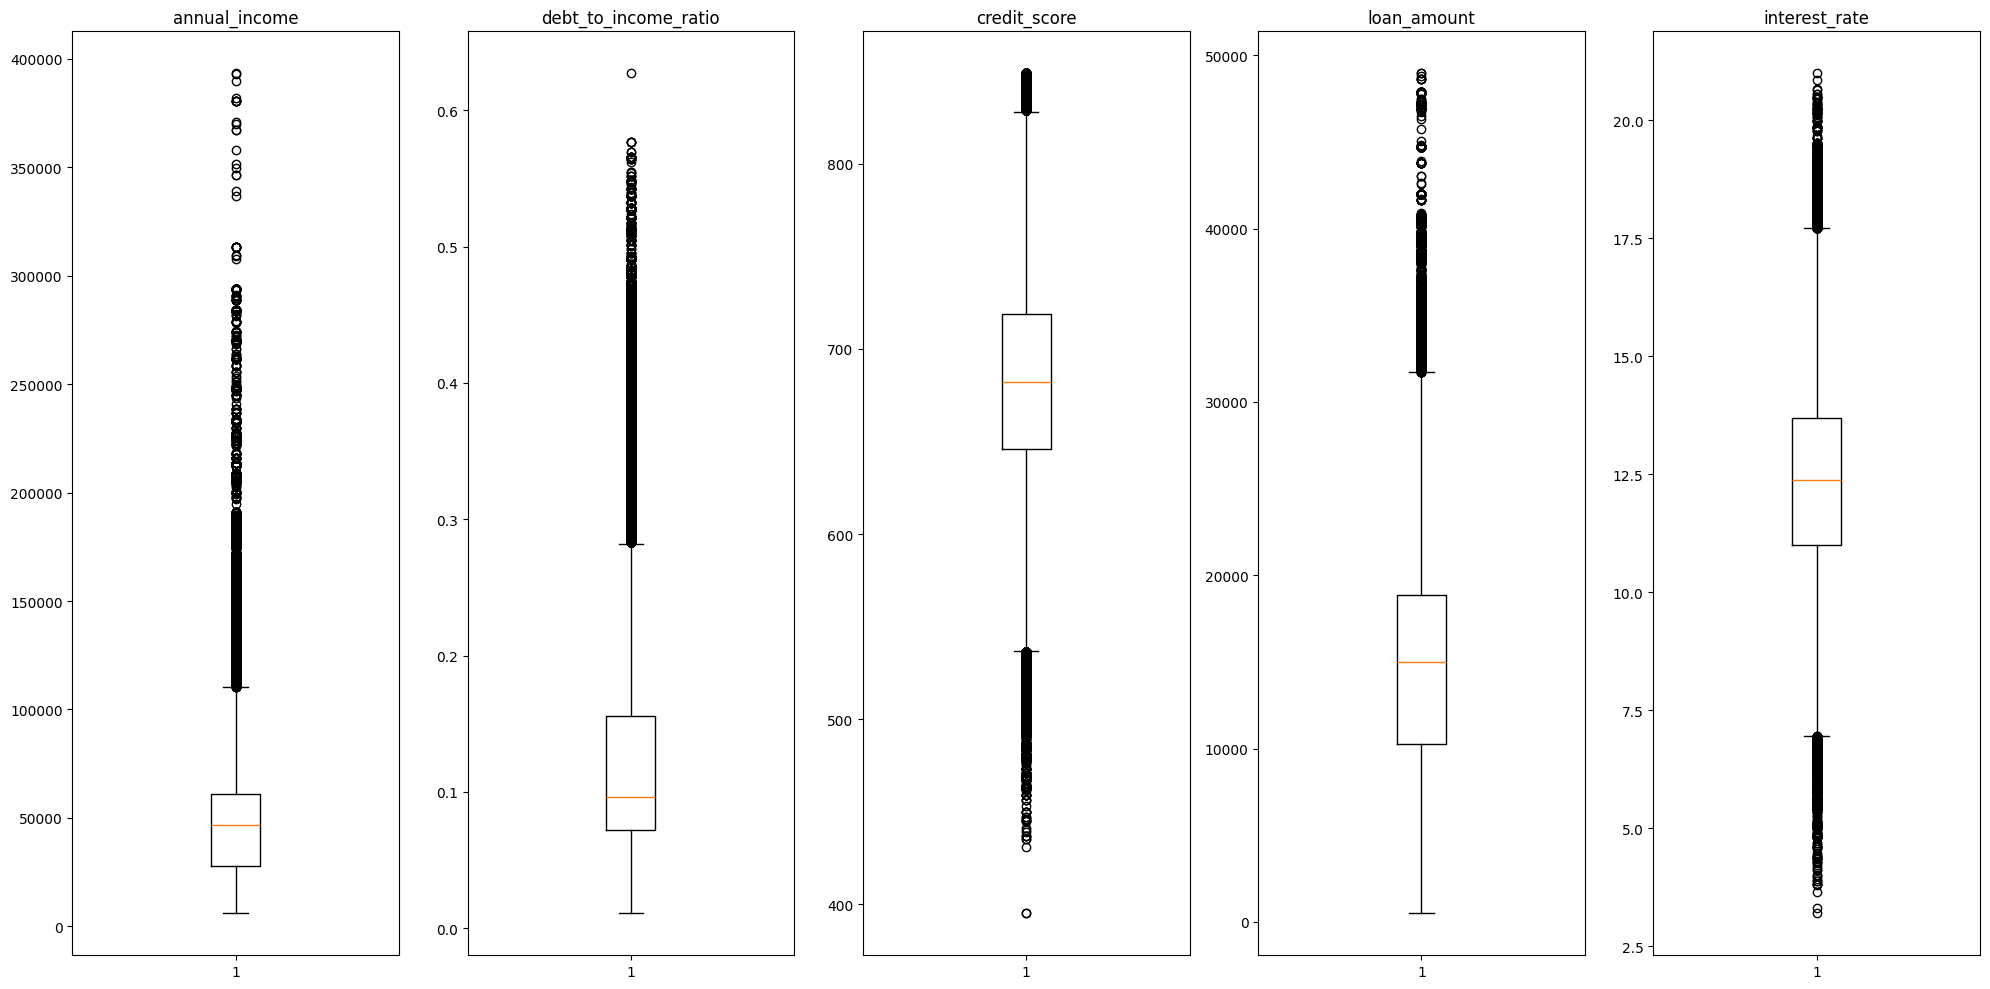

In [23]:
fig, axes = plt.subplots(1, len(numerical_cols), figsize=(20, 10))

for i, col in enumerate(numerical_cols):
    axes[i].boxplot(train[col], vert=True)
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

- Overall the visualization confirms statistical IQR outlier analysis
- `annual_income` has the most extreme outliers stretching far above the box
- `debt_to_income_ratio` has numerous but less extreme ones
- The remaining three features are largely clean with only minor outliers visible.

### Additionally ###

all numerical features may require scaling — they're on different scales:

- `annual_income`: 6k–393k
- `credit_score`: 395–849
- `loan_amount`: 500–49k
- `debt_to_income_ratio`: 0.01–0.63
- `interest_rate`: 3.2–21

## Bivariate analysis ##

In [24]:
train.groupby('loan_paid_back')[numerical_cols].agg(['mean', 'median']).round(2)

annual_income           debt_to_income_ratio         \
                        mean    median                 mean median   
loan_paid_back                                                       
0.0                  47875.5  45935.39                 0.17   0.16   
1.0                  48297.0  46664.37                 0.11   0.09   

               credit_score        loan_amount           interest_rate         
                       mean median        mean    median          mean median  
loan_paid_back                                                                 
0.0                  655.01  657.0    15072.22  15078.79         12.88  12.88  
1.0                  687.44  688.0    15007.22  14957.85         12.22  12.25

**Observations (Numerical Features vs Target):**
- `credit_score`: strong separator — defaulters score ~32 points lower (655 vs 687)
- `debt_to_income_ratio`: strongest separator — defaulters have 55% higher ratio (0.17 vs 0.11), median confirms (not skew-driven)
- `interest_rate`: modest signal — defaulters pay slightly higher rates
- `annual_income`: very similar medians — weak predictor
- `loan_amount`: near-identical — the weakest predictor

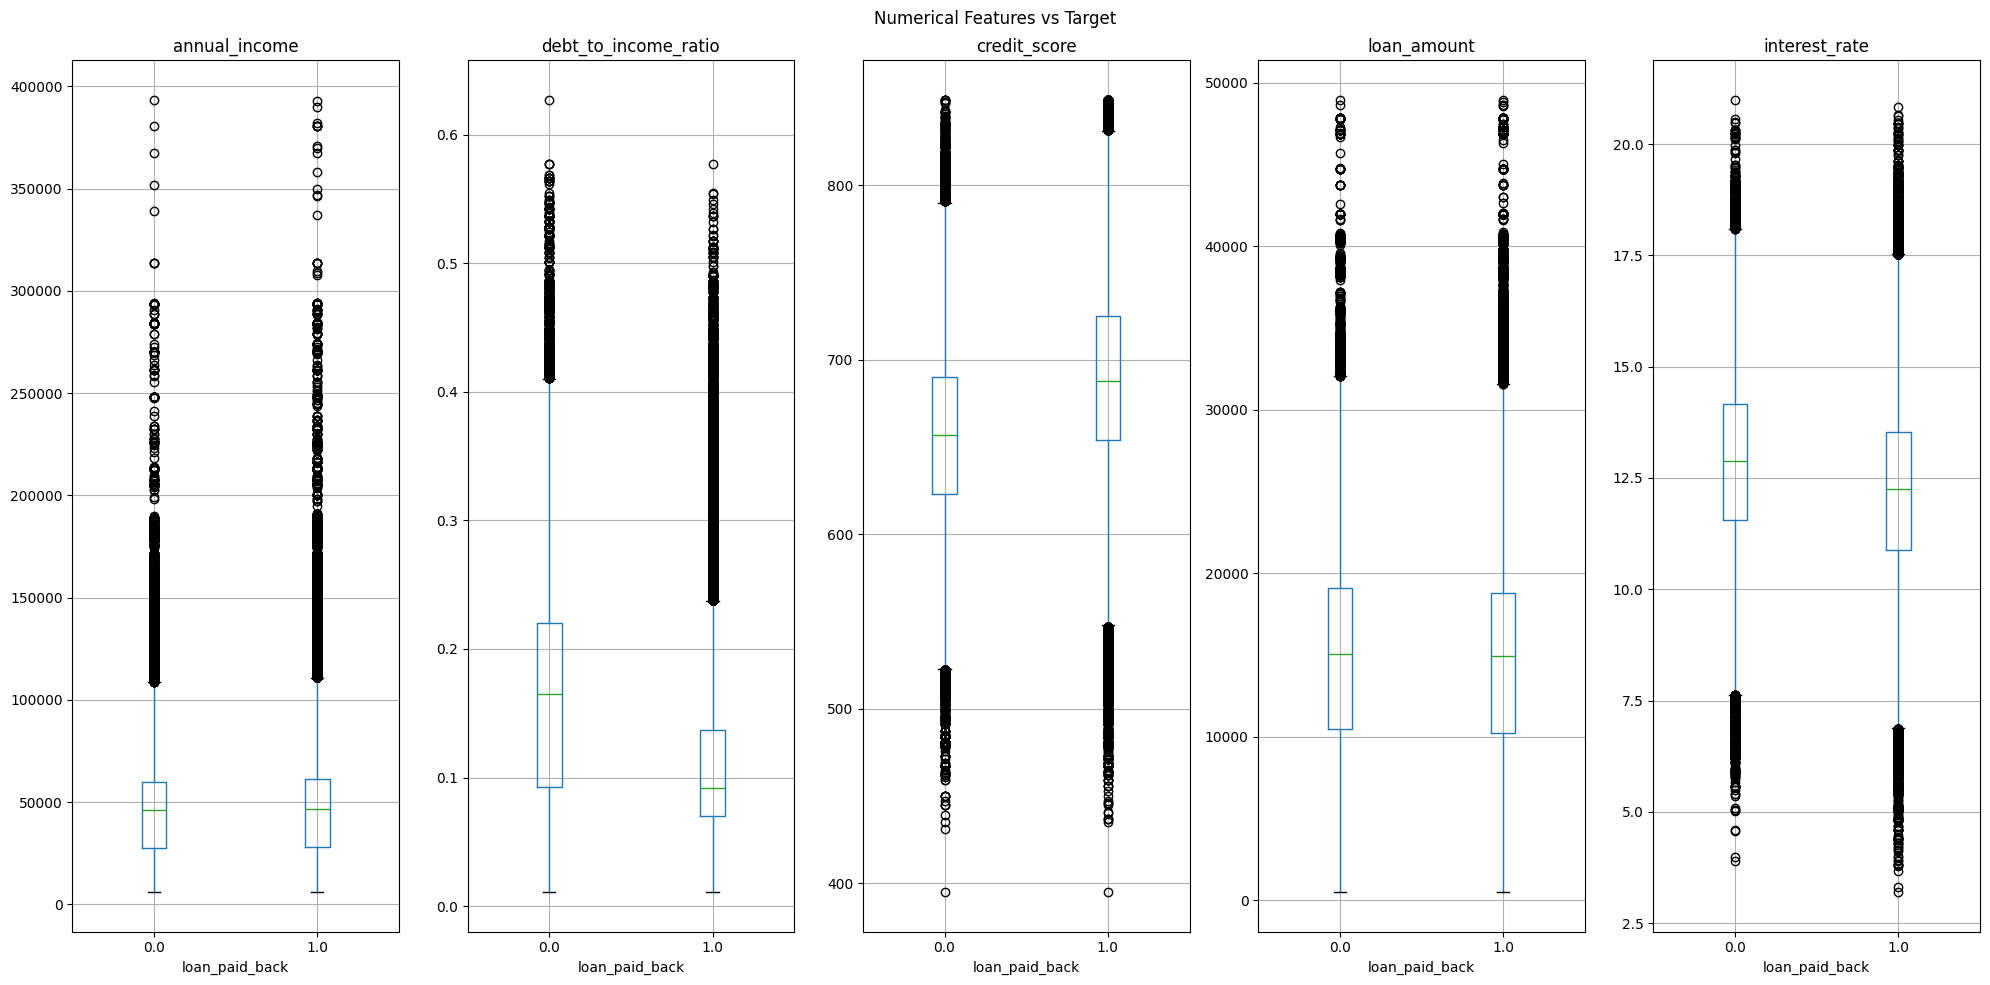

In [25]:
fig, axes = plt.subplots(1, len(numerical_cols), figsize=(20, 10))

for i, col in enumerate(numerical_cols):
    train.boxplot(column=col, by='loan_paid_back', ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel('loan_paid_back')

plt.suptitle('Numerical Features vs Target')
plt.tight_layout()
plt.show()

- Visually confirms statistical observations - no surprise

In [26]:
for col in categorical_cols:
    print(train.groupby(col)['loan_paid_back'].mean().round(3).sort_values())
    print()

gender
Other     0.795
Male      0.796
Female    0.802
Name: loan_paid_back, dtype: float64

marital_status
Widowed     0.790
Divorced    0.797
Married     0.799
Single      0.799
Name: loan_paid_back, dtype: float64

education_level
Bachelor's     0.789
Master's       0.802
Other          0.803
High School    0.810
PhD            0.830
Name: loan_paid_back, dtype: float64

employment_status
Unemployed       0.078
Student          0.264
Employed         0.894
Self-employed    0.898
Retired          0.997
Name: loan_paid_back, dtype: float64

loan_purpose
Education             0.777
Medical               0.778
Vacation              0.796
Debt consolidation    0.797
Car                   0.801
Other                 0.802
Business              0.813
Home                  0.823
Name: loan_paid_back, dtype: float64

grade_subgrade
F3    0.604
F2    0.618
F1    0.625
F4    0.637
F5    0.639
E3    0.642
E4    0.650
E1    0.652
E2    0.663
E5    0.669
D3    0.696
D5    0.713
D4    0.715
D2    

**Observations (Categorical Features vs Target):**
- `employment_status`: strongest categorical predictor — Unemployed repay only 7.8%, Retired nearly 99.7%
- `grade_subgrade`: strong ordinal signal — F-grades ~60%, A-grades ~95% repayment
- `loan_purpose`: modest signal — Education/Medical lowest (~77.7%), Home highest (~82.3%)
- `education_level`: weak signal — natural ordinal order not confirmed in data (High School 81.0% > Bachelor's 78.9%), encoding strategy to be determined
- `gender`: no signal — all categories ~79.5-80.2%
- `marital_status`: no signal — all categories ~79.0-79.9%

In [27]:
for col in categorical_cols:
    ct = pd.crosstab(train[col], train['loan_paid_back'])
    chi2, p, dof, _ = chi2_contingency(ct)
    n = ct.sum().sum()
    cramers_v = np.sqrt(chi2 / (n * (min(ct.shape) - 1)))
    print(f"{col}: Cramér's V = {cramers_v:.3f}")

gender: Cramér's V = 0.007
marital_status: Cramér's V = 0.003
education_level: Cramér's V = 0.025
employment_status: Cramér's V = 0.657
loan_purpose: Cramér's V = 0.026
grade_subgrade: Cramér's V = 0.228


**Observations (Cramér's V):**
- `employment_status`: 0.657 — strongest categorical predictor by far
- `grade_subgrade`: 0.228 — strong association confirmed
- `loan_purpose`: 0.026 — weak signal
- `education_level`: 0.025 — weak signal  
- `gender`: 0.007 — no meaningful association
- `marital_status`: 0.003 — no meaningful association

Cramer V confirms earlier conclusions.

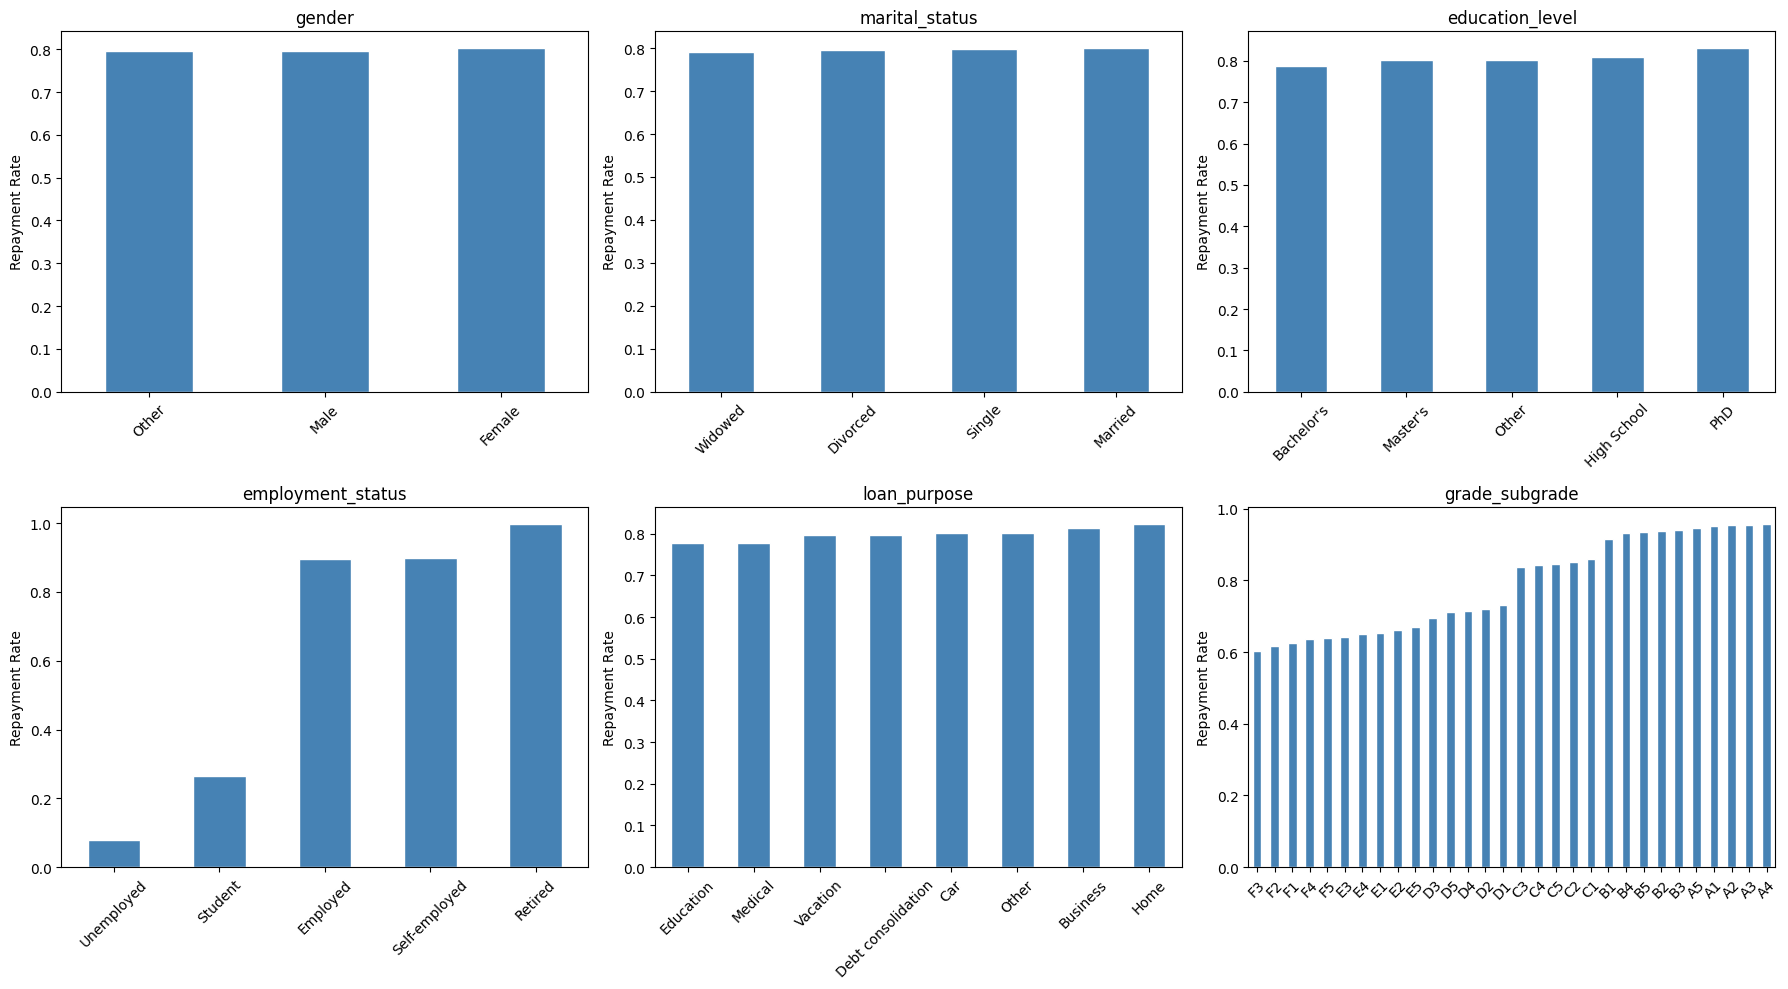

In [28]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    repay_rate = train.groupby(col)['loan_paid_back'].mean().sort_values()
    repay_rate.plot(kind='bar', ax=axes[i], color='steelblue', edgecolor='white')
    axes[i].set_title(col)
    axes[i].set_ylabel('Repayment Rate')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

- all conclusions visually confirmed

**Grade Subgrade Deep Dive**

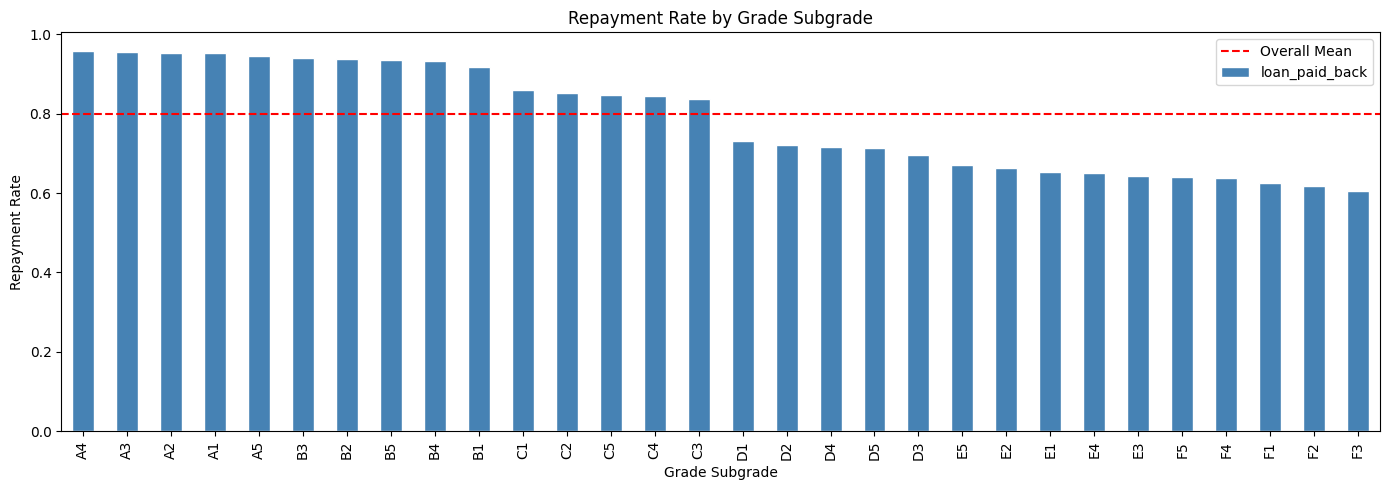

In [29]:
grade_repay = train.groupby('grade_subgrade')['loan_paid_back'].mean().sort_values(ascending=False)

grade_repay.plot(kind='bar', figsize=(14, 5), color='steelblue', edgecolor='white')
plt.title('Repayment Rate by Grade Subgrade')
plt.ylabel('Repayment Rate')
plt.xlabel('Grade Subgrade')
plt.axhline(y=train['loan_paid_back'].mean(), color='red', linestyle='--', label='Overall Mean')
plt.legend()
plt.tight_layout()
plt.show()

**Observations (Grade Subgrade Deep Dive):**
- Ordinal structure confirmed — repayment rate decreases monotonically from A to F grades
- A-grades: ~95% repayment, all well above overall mean (0.80)
- B/C-grades: straddle the mean — C3 is the clear cutoff point where grades drop below average
- D/E/F-grades: all below mean, F-grades bottom out at ~60%
- 35-point spread (60% to 95%) — largest repayment range of any feature, confirming grade_subgrade as the strongest categorical predictor

## Multivariate analysis

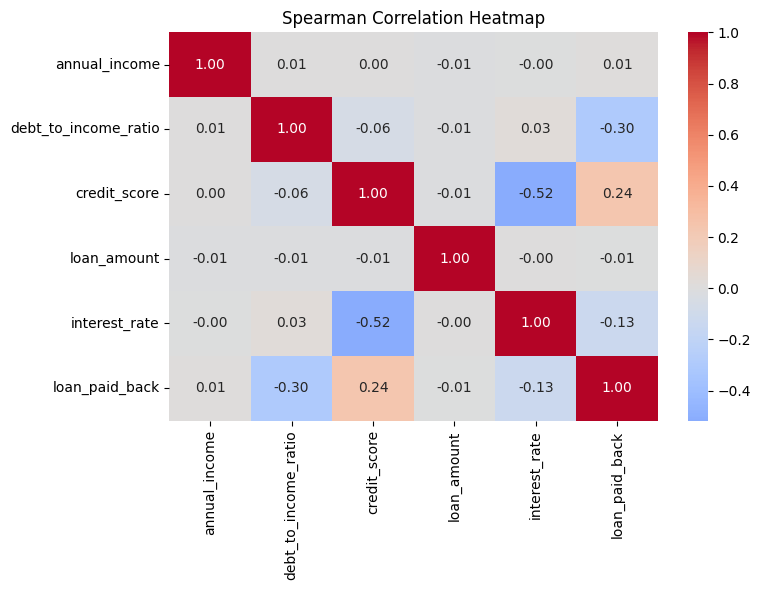

In [30]:
corr = train[numerical_cols + ['loan_paid_back']].corr(method='spearman') 

# spearman is more robust to outliers and non-normal distributions than pearson, 
# which is appropriate given the skewness and outliers.


plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Spearman Correlation Heatmap')
plt.tight_layout()
plt.show()

**Observations (Spearman Correlation Heatmap):**
- No significant multicollinearity
- `credit_score` ↔ `interest_rate`: -0.52 — strongest feature relationship, moderate but not concerning
- `debt_to_income_ratio` → `loan_paid_back`: -0.30 — strongest numerical predictor of target
- `credit_score` → `loan_paid_back`: 0.24 — second strongest numerical predictor
- `interest_rate` → `loan_paid_back`: -0.13 — weak signal
- `annual_income` and `loan_amount`: near-zero correlation with target — confirmed weak predictors

<h1 align="center">Final Summary Section</h1>

### Train and Test datasets
- no missing values, no duplicates, no unrealistic values and no distribution drift

### Dataset Shape
- 593,994 rows, 13 columns (11 features + 1 target + id)
- 5 numerical features, 6 categorical features, 1 target variable
- `loan_paid_back`: binary target (0.0/1.0), 80/20 class imbalance

### Target Variable
- 80/20 class imbalance.

### Key Predictors (Strongest → Weakest)
**Categorical:**
- `employment_status` — strongest signal (Cramér's V: 0.657), 92-point repayment spread
- `grade_subgrade` — strong confirmed ordinal signal (Cramér's V: 0.228), 35-point spread F→A
- `loan_purpose` — weak signal (Cramér's V: 0.026)
- `education_level` — weak signal (Cramér's V: 0.025), ordinal order broken in data
- `gender` & `marital_status` — no meaningful signal, consider dropping

**Numerical:**
- `debt_to_income_ratio` — strongest numerical predictor (Spearman: -0.30)
- `credit_score` — second strongest (Spearman: 0.24)
- `interest_rate` — weak signal (Spearman: -0.13)
- `annual_income` & `loan_amount` — near-zero correlation with target, weakest predictors

### Distributions & Outliers
**Skewness:**
- `annual_income`: 1.72 — strong right skew
- `debt_to_income_ratio`: 1.41 — strong right skew
- `loan_amount`: 0.21 — mild right skew
- `credit_score`: -0.17 — approximately normal
- `interest_rate`: 0.05 — approximately normal

**Kurtosis:**
- `annual_income`: 7.09 — extremely heavy tails, extreme outliers likely
- `debt_to_income_ratio`: 2.34 — moderately heavy tails
- `loan_amount`: -0.15 — lighter tails, non-normality driven by clustering
- `credit_score` & `interest_rate`: ~0 — normal tail behavior

**IQR Outlier Check:**
- `annual_income`: 2.68% — few but extreme
- `debt_to_income_ratio`: 2.96% — numerous but less extreme
- `loan_amount`, `credit_score`, `interest_rate`: under 1% — minor

### Multicollinearity
- No significant multicollinearity detected.
- `credit_score` and `interest_rate` only share a moderate relationship.

### Preprocessing & Feature Engineering Recommendations
- `id`: dropping recommended (sequential, no predictive value)
- `loan_paid_back`: casting to int recommended (target variable)
- `annual_income` & `debt_to_income_ratio`: log transformation + optional outlier handling recommended for linear models
- `grade_subgrade`: ordinal encoding recommended (confirmed monotonic A→F structure, high cardinality — 30 unique values)
- `education_level`: one-hot encoding recommended (ordinal order broken in data)
- `employment_status`, `loan_purpose`, `gender`, `marital_status`: one-hot encoding recommended if linear model
- All numerical features: scaling recommended for linear models, not needed for tree-based
- Rare categories (Other in gender, Widowed, Divorced): grouping recommended depending on model 
- class imbalance — may require handling (class weights or threshold tuning) depending on model choice. Less critical given AUC as evaluation metric.


<h1 align="center">Model Selection</h1>

Given:
- Mixed feature types (numerical + categorical)
- Non-normal distributions with outliers in key features
- Strong non-linear signals in `employment_status` and `grade_subgrade`
- AUC as evaluation metric


**Primary: Tree-based models (LightGBM / CatBoost / XGBoost)**
- Robust to skewness and outliers — no transformation required
- Handles mixed feature types natively
- Captures non-linear relationships naturally
- No scaling required
- Well-suited for AUC optimization

**More detailed**
- XGBoost / LightGBM: fast, well-optimized for AUC, require encoding
- CatBoost: handles categorical features natively — particularly relevant given 6 categorical features

**Note**
- Worth trying ensemble of XGBoost / LightGBM / CatBoost

**Justification**
- Linear models (Logistic Regression, SVM) would require scaling, transformation, explicit encoding, and outlier handling — significant preprocessing overhead with no AUC advantage over tree-based models
- Neural networks are overkill for tabular data of this size — harder to tune, no significant AUC advantage over GBMs on structured data
- Tree-based model or their ensemble (like LGB + XGB + CatBoost which is usually more efficient) handles skewness, outliers, mixed types, and non-linear interactions natively — consistently wins on tabular competitions and is the most optimal choice given no specific business requirements except competition effectiveness (AUC)


